## Bootstrap (click Run All — no setup required)

This cell makes the notebook self-installing. It:

1. Finds the Lunar-V2 repo root and puts it on `sys.path`.
2. Installs any missing third-party packages (`numpy`, `scipy`, `numba`, `matplotlib`, plus extras) into the current kernel.
3. Downloads any external data files this notebook needs.

You can re-run it any time; it's a no-op if everything is already present.

In [1]:
# === Lunar-V2 notebook bootstrap — safe to re-run ===
import sys, pathlib
# Locate the repo root even if this notebook is opened from a weird CWD.
_here = pathlib.Path.cwd().resolve()
for _p in (_here, *_here.parents):
    if (_p / 'pyproject.toml').is_file() and (_p / 'lunar' / '_bootstrap.py').is_file():
        if str(_p) not in sys.path:
            sys.path.insert(0, str(_p))
        break
else:
    raise RuntimeError('Could not find Lunar-V2 repo root from ' + str(_here))

from lunar import _bootstrap as boot
boot.ensure_lunar(extra=())

boot.ensure_apollo_hfe()


Lunar-V2 notebook bootstrap
  python : /usr/local/bin/python3
  repo   : /Users/rp3gregorio/Documents/Lunar-V2
  deps   : all present
  lunar  : /Users/rp3gregorio/Documents/Lunar-V2/lunar/__init__.py
Ensuring Apollo HFE (a15) ...


True

# Apollo 15 HFE Validation

Compare the Lunar-V2 1-D thermal solver against the Apollo 15 Heat Flow Experiment (HFE)
temperature data (Nagihara et al. 2018, PDS bundle
`urn:nasa:pds:a15_17_hfe_concatenated`).

**Apollo 15 site**: 26.13 °N, 3.63 °E (Mare Imbrium, 1971-2011 continuous record).

**Validation approach** (following Lunar-Clean methodology):

1. Load the **depth table** (gradient-bridge TG + reference TR sensors) from both probes.
   These give actual temperatures at known burial depths, unlike the fast-sensor channels
   which aggregate multiple sensors per file.
2. Extract **equilibrium temperatures** from the stable tail (last 25%) of each sensor's
   time series. By this point the initial drilling disturbance has decayed.
3. **Filter to deep sensors (≥ 80 cm)** for RMSE validation. Shallower sensors sit within
   the diurnal skin depth (~50 cm) and are biased by probe hardware solar heating; including
   them inflates the apparent model error by 2–4 K (see Lunar-Clean `constants.py`
   documentation).
4. Use **site-specific basal heat flux** Q\_basal = 21 mW/m² for Apollo 15 (Langseth et al.
   1976, Nagihara et al. 2018), not the generic 18 mW/m² average.
5. **Equilibrium profile initialization**: `T(z) = T_mean_surface + Q_b × R(z)` where
   R(z) is the cumulative thermal resistance. This avoids the multi-year convergence
   timescale at depths > 50 cm that makes uniform-T initialization fail.

In [2]:
from __future__ import annotations
import sys, pathlib, os

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec

from lunar.validation import load_apollo_hfe_temperature, load_apollo_hfe_depth
from lunar.grid import make_geometric_grid
from lunar.properties import conductivity_hayne, density_hayne, specific_heat
from lunar.constants import (
    SIGMA_SB, EMISSIVITY_DEFAULT, CHI_RADIATIVE, T_REFERENCE,
)
from lunar.solver import PixelInputs, solve_pixel
from lunar.plotting.style_guide import (
    apply_style, COLORS, panel_label, save_figure,
    legend_outside, add_colorbar,
    FIG_DOUBLE, FIG_DOUBLE_TALL, FIG_FULL_PAGE,
)

apply_style()

REPO_ROOT = str(_p)
OUTPUT_DIR = os.path.join(REPO_ROOT, 'output', 'figures')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Apollo 15 site-specific basal heat flux — Langseth et al. (1976)
Q_BASAL_A15 = 0.021  # W/m² (21 mW/m²)
# Minimum depth for RMSE validation — shallow sensors are diurnally active
MIN_DEPTH_CM = 80

print('Imports OK — publication style applied')
print(f'Figures → {OUTPUT_DIR}')

Imports OK


## 1  Load the Apollo 15 HFE depth-table data

The PDS depth tables give calibrated temperature at each gradient-bridge (TG) and
reference-thermocouple (TR) sensor at their known burial depths. Two probes:

| Probe | Sensor | Depth (cm) | Type |
|-------|--------|-----------|------|
| 1 | TG11A | 35  | TG (diurnal zone) |
| 1 | TG11B | 84  | TG |
| 1 | TG12A | 91  | TG |
| 1 | TG12B | 139 | TG |
| 1 | TR11A | 45  | TR (diurnal zone) |
| 1 | TR11B | 73  | TR |
| 1 | TR12A | 101 | TR |
| 1 | TR12B | 129 | TR |
| 2 | TG22A | 49  | TG (diurnal zone) |
| 2 | TG22B | 97  | TG |
| 2 | TR22A | 59  | TR (diurnal zone) |
| 2 | TR22B | 87  | TR |

Equilibrium temperatures are extracted from a **data-driven stabilized tail** per
sensor: the earliest tail segment whose long-term trend is near-flat. If no segment
meets the flat-trend criterion, we fall back to the last 25% of the record.

In [35]:
# Load depth tables for both probes
d1 = load_apollo_hfe_depth('a15', 1)
d2 = load_apollo_hfe_depth('a15', 2)

print(f'Probe 1: {len(d1):,} records, sensors: {np.unique(d1["sensor"])}')
print(f'         depths [cm]: {np.unique(d1["depth_cm"])}')
print(f'Probe 2: {len(d2):,} records, sensors: {np.unique(d2["sensor"])}')
print(f'         depths [cm]: {np.unique(d2["depth_cm"])}')

from datetime import datetime, timezone


def iso_to_seconds(iso_arr):
    """Convert ISO strings to Unix seconds."""
    out = np.empty(len(iso_arr), dtype=np.float64)
    for i, s in enumerate(iso_arr):
        s = s.strip()
        if s.endswith('Z'):
            s = s[:-1] + '+00:00'
        dt = datetime.fromisoformat(s).replace(tzinfo=timezone.utc)
        out[i] = dt.timestamp()
    return out


def choose_stable_tail(subset, min_frac=0.20, slope_thresh_K_per_year=0.08):
    """Pick stabilized tail using trend criterion; fallback to last 25%."""
    n = len(subset)
    t_sec = iso_to_seconds(subset['time_iso'])
    t_year = (t_sec - t_sec[0]) / (365.25 * 86400.0)
    T = subset['T'].astype(np.float64)

    candidates = np.linspace(0.55, 0.85, 13)
    chosen_i = int(0.75 * n)
    method = 'fallback_last25'
    slope_out = np.nan

    for frac in candidates:
        i0 = int(frac * n)
        if n - i0 < max(40, int(min_frac * n)):
            continue
        x = t_year[i0:]
        y = T[i0:]
        if np.ptp(x) <= 0:
            continue
        slope, _ = np.polyfit(x, y, 1)  # K/year
        if abs(slope) <= slope_thresh_K_per_year:
            chosen_i = i0
            method = 'trend_flat'
            slope_out = float(slope)
            break

    if np.isnan(slope_out):
        x = t_year[chosen_i:]
        y = T[chosen_i:]
        if np.ptp(x) > 0:
            slope_out = float(np.polyfit(x, y, 1)[0])

    return chosen_i, method, slope_out


# Extract equilibrium temperature from stabilized tail per sensor
sensors_all = []

for probe_num, dtab in [(1, d1), (2, d2)]:
    for sensor in np.unique(dtab['sensor']):
        mask = dtab['sensor'] == sensor
        subset = dtab[mask]
        n = len(subset)

        i_start, method, slope = choose_stable_tail(subset)
        tail = subset[i_start:]

        depth = float(np.unique(tail['depth_cm'])[0])
        T_eq = float(np.mean(tail['T']))
        T_std = float(np.std(tail['T']))
        stype = sensor.strip()[:2]

        sensors_all.append({
            'sensor': sensor.strip(),
            'depth_cm': depth,
            'T_eq': T_eq,
            'T_std': T_std,
            'n_tail': len(tail),
            'stype': stype,
            'probe': probe_num,
            'tail_start_frac': i_start / n,
            'stable_method': method,
            'tail_slope_Kyr': slope,
        })

# Sort by depth
sensors_all.sort(key=lambda s: s['depth_cm'])

print('\nEquilibrium temperatures (stabilized tail):')
print(f'{"Sensor":<8} {"Probe":>5} {"Depth":>7} {"Type":>4} {"T_eq (K)":>9} {"σ (K)":>7} '
      f'{"tail%":>7} {"slope[K/yr]":>11} {"Method":>15} {"In val?":>7}')
print('-' * 108)
for s in sensors_all:
    in_val = '✓' if s['depth_cm'] >= MIN_DEPTH_CM else '·'
    print(f'{s["sensor"]:<8} {s["probe"]:>5d} {s["depth_cm"]:>7.0f} {s["stype"]:>4} '
          f'{s["T_eq"]:>9.2f} {s["T_std"]:>7.3f} {100*s["tail_start_frac"]:>6.1f}% '
          f'{s["tail_slope_Kyr"]:>+11.3f} {s["stable_method"]:>15} {in_val:>7}')

# Build arrays for validation
depth_cm_all = np.array([s['depth_cm'] for s in sensors_all])
T_eq_all     = np.array([s['T_eq']     for s in sensors_all])
T_std_all    = np.array([s['T_std']    for s in sensors_all])
stype_all    = [s['stype'] for s in sensors_all]

# Deep sensors only (≥ 80 cm) for RMSE calculation
deep_mask     = depth_cm_all >= MIN_DEPTH_CM
depth_cm_deep = depth_cm_all[deep_mask]
T_eq_deep     = T_eq_all[deep_mask]
print(f'\nDeep sensors (≥ {MIN_DEPTH_CM} cm) for validation: {deep_mask.sum()}')

Probe 1: 187,882 records, sensors: ['TG11A' 'TG11B' 'TG12A' 'TG12B' 'TR11A' 'TR11B' 'TR12A' 'TR12B']
         depths [cm]: [ 35.  45.  73.  84.  91. 101. 129. 139.]
Probe 2: 92,028 records, sensors: ['TG22A' 'TG22B' 'TR22A' 'TR22B']
         depths [cm]: [49. 59. 87. 97.]

Equilibrium temperatures (stabilized tail):
Sensor   Probe   Depth Type  T_eq (K)   σ (K)   tail% slope[K/yr]          Method In val?
------------------------------------------------------------------------------------------------------------
TG11A        1      35   TG    253.64   1.891   75.0%     +10.353 fallback_last25       ·
TR11A        1      45   TR    253.12   0.684   57.4%      +0.024      trend_flat       ·
TG22A        2      49   TG    249.97   0.612   75.0%      +1.641 fallback_last25       ·
TR22A        2      59   TR    249.99   0.260   55.0%      +0.023      trend_flat       ·
TR11B        1      73   TR    253.00   0.103   75.0%      +0.191 fallback_last25       ·
TG11B        1      84   TG    25

In [38]:
# Plot the full temperature time series from both probes, coloured by depth
SECONDS_PER_YEAR = 365.25 * 86400.0
cmap = plt.get_cmap('viridis_r')
norm = plt.Normalize(vmin=min(depth_cm_all), vmax=max(depth_cm_all))

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False,
                         constrained_layout=True)

for ax, probe_num, dtab, title in zip(axes, [1, 2], [d1, d2],
                                        ['Probe 1', 'Probe 2']):
    t0 = None
    for sensor in np.unique(dtab['sensor']):
        mask = dtab['sensor'] == sensor
        subset = dtab[mask]
        depth = float(np.unique(subset['depth_cm'])[0])
        color = cmap(norm(depth))
        stype = sensor.strip()[:2]
        ls = '-' if stype == 'TG' else '--'
        lw = 1.2 if depth >= MIN_DEPTH_CM else 0.7
        alpha = 0.9 if depth >= MIN_DEPTH_CM else 0.4

        # Time: parse ISO strings to seconds since first record
        import datetime
        times_s = []
        for t_str in subset['time_iso']:
            dt_obj = datetime.datetime.fromisoformat(t_str.replace('Z', '+00:00'))
            times_s.append(dt_obj.timestamp())
        times_s = np.array(times_s)
        if t0 is None:
            t0 = times_s[0]
        yr = (times_s - t0) / SECONDS_PER_YEAR

        in_val = depth >= MIN_DEPTH_CM
        tag = '' if in_val else ' (excl.)'
        ax.plot(yr, subset['T'], lw=lw, ls=ls, color=color, alpha=alpha,
                label=f'{sensor.strip()} ({depth:.0f} cm){tag}')

    ax.set_xlabel('Years after deployment')
    ax.set_ylabel('Temperature (K)')
    ax.set_title(f'Apollo 15 HFE — {title}', fontsize=11, weight='bold')
    ax.legend(fontsize=6.8, ncol=2, loc='upper left',
              bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0,
              framealpha=0.9, columnspacing=0.8, handlelength=2.0)

fig.suptitle('Apollo 15 — HFE Probe Temperature History\n'
             'Solid = TG (gradient bridge)  ·  Dashed = TR (reference TC)  ·  '
             f'Dim = excluded from validation (< {MIN_DEPTH_CM} cm)',
             fontsize=11, weight='bold')
fig.savefig('../data/apollo/a15_p1_timeseries.png', dpi=150)
print('Saved a15_p1_timeseries.png')
plt.close(fig)

Saved a15_p1_timeseries.png


In [39]:
# Show the equilibrium temperature profile from both probes
fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)

_stype_marker = {'TG': 'o', 'TR': 's'}
_stype_label  = {'TG': 'TG (gradient bridge)', 'TR': 'TR (reference TC)'}
_stype_ms     = {'TG': 9, 'TR': 7}
_stype_alpha  = {'TG': 1.0, 'TR': 0.7}

# Diurnal zone shading
ax.axhspan(0, MIN_DEPTH_CM, color='#FFF3CD', alpha=0.55, zorder=0)
ax.axhline(MIN_DEPTH_CM, color='#CC8800', lw=0.9, ls='--', alpha=0.65, zorder=1)
ax.text(0.99, MIN_DEPTH_CM - 2, 'Diurnal zone (< 80 cm)',
        fontsize=7, color='#996600', va='bottom', ha='right',
        transform=ax.get_yaxis_transform())

for stype in ['TG', 'TR']:
    mask = np.array([s == stype for s in stype_all])
    if mask.any():
        ax.errorbar(
            T_eq_all[mask], depth_cm_all[mask],
            xerr=T_std_all[mask],
            fmt=_stype_marker[stype], markersize=_stype_ms[stype],
            color='#1A5276', capsize=3, alpha=_stype_alpha[stype],
            markeredgewidth=1.2, markeredgecolor='white',
            label=_stype_label[stype], zorder=5,
        )

ax.invert_yaxis()
ax.set_xlabel('Equilibrium Temperature (K)', fontsize=11, weight='bold')
ax.set_ylabel('Depth (cm)', fontsize=11, weight='bold')
ax.set_title('Apollo 15 — Equilibrium Temperature Profile\n'
             '(stable tail, trend-flat criterion)',
             fontsize=12, weight='bold')
ax.legend(fontsize=9, loc='upper left',
          bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
ax.grid(True, alpha=0.3)

plt.close(fig)
print('Equilibrium profile plotted')

Equilibrium profile plotted


## 2  Run the 1-D solver at Apollo 15 coordinates

Surface driven with sinusoidal insolation at 26.13 °N. Key improvements
over the naive approach:

1. **Equilibrium profile initialization** — `T(z) = T_surf_mean + Q_b × R(z)`.
   At 1 m depth the thermal equilibration timescale exceeds one year, so a
   short spin-up starting from a uniform T never converges. The equilibrium
   profile places the deep temperature within ~1 K of the correct value
   immediately.
2. **Site-specific basal heat flux** — 21 mW/m² (Apollo 15, Langseth 1976)
   instead of the generic 18 mW/m² average.
3. **15-lunation spin-up** — converges the diurnal layer; the deep layers
   are already correct from the initialization.

In [13]:
# Apollo 15 site parameters
LAT_A15  = 26.13   # deg N
ALBEDO   = 0.12    # Hayne 2017 nominal (disturbed regolith at drill site)
EMIS     = EMISSIVITY_DEFAULT  # 0.95

# Lunar sidereal period ≈ 27.32 days
T_LUNAR  = 27.321661 * 86400.0   # s
S0       = 1361.0                 # W m^-2 solar constant
cos_lat  = np.cos(np.deg2rad(LAT_A15))

# One lunation, 3600-s time steps
dt_step  = 3600.0
N_t      = int(T_LUNAR / dt_step) + 1
t_s      = np.linspace(0.0, T_LUNAR, N_t)

# Sinusoidal insolation
phase      = 2.0 * np.pi * t_s / T_LUNAR
insolation = S0 * cos_lat * np.maximum(0.0, np.cos(phase))

# Geometric grid
grid = make_geometric_grid(z_max=5.0, dz0=0.002, growth=0.08)
print(f'Grid: {grid.n_layers} layers,  z_max = {grid.z_mid[-1]:.2f} m')

# ===========================================================================
# Equilibrium profile initialisation: T(z) = T_mean_eff + Q_b * R(z)
#
# T_mean_eff ≈ 250 K for the Apollo 15 drill site — significantly warmer
# than the pristine radiative equilibrium (~213 K) because:
#   1. Astronaut foot traffic darkened the local surface (lower albedo)
#   2. The bore-stem acts as a thermal short-circuit to depth
#   3. Three+ years of elevated surface absorption accumulated at depth
# This follows Lunar-Clean: "use ~250 K for A15 lat" (see solver.py docs).
# ===========================================================================
T_MEAN_EFF = 250.0  # K — effective mean surface T at the disturbed drill site

z_mid = grid.z_mid
K_init = conductivity_hayne(np.full_like(z_mid, T_MEAN_EFF), z_mid)

# Cumulative thermal resistance R(z)
R_z = np.cumsum(grid.dz / K_init)
T_init = T_MEAN_EFF + Q_BASAL_A15 * R_z

print(f'T_mean_eff (drill site) = {T_MEAN_EFF:.0f} K')
print(f'T_init  surface : {T_init[0]:.2f} K')
print(f'T_init  at 1 m  : {np.interp(1.0, z_mid, T_init):.2f} K')
print(f'T_init  at 1.4 m: {np.interp(1.4, z_mid, T_init):.2f} K')

# Solver inputs — 15-lunation spin-up
inputs = PixelInputs(
    grid=grid, t=t_s, bc_mode='radiative',
    insolation=insolation, albedo=ALBEDO, emissivity=EMIS,
    Q_b=Q_BASAL_A15, T_init=T_init,
    n_lunations_spinup=15, spinup_tol_K=0.01,
)

print(f'\nRunning solver (Q_b = {Q_BASAL_A15*1e3:.0f} mW/m², 15-lunation spin-up)...')
out = solve_pixel(inputs)
delta = out.diagnostics.get('last_cycle_max_dT', float('nan'))
print(f'  Spin-up: {out.n_spinup_cycles} cycles,  converged={out.converged},  dT_last={delta:.4f} K')
print(f'  Mean surface T = {float(np.mean(out.T_surface)):.1f} K')

Grid: 69 layers,  z_max = 4.85 m
T_mean_eff (drill site) = 250 K
T_init  surface : 250.03 K
T_init  at 1 m  : 253.52 K
T_init  at 1.4 m: 254.81 K

Running solver (Q_b = 21 mW/m², 15-lunation spin-up)...
  Spin-up: 15 cycles,  converged=False,  dT_last=0.0135 K
  Mean surface T = 213.5 K


## 2b  Discrete Layer Model  —  Apollo-Calibrated Alternative

The **Hayne et al. (2017)** model uses an exponential H-parameter to smoothly
transition thermal properties from the fluffy surface to the consolidated
subsurface. This was calibrated against **Diviner surface brightness
temperatures** — i.e. the diurnal skin depth (~top 20 cm).

The **Discrete Layer** model (Lunar-Clean; Gregorio 2026) instead defines
three sharp thermophysical layers calibrated directly against the **Apollo HFE
subsurface heat-flow measurements** (Langseth et al. 1976):

| Layer | Depth Range | k_solid (W/m/K) | ρ (kg/m³) | Calibration |
|-------|-------------|-----------------|----------|-------------|
| 1 — Fluffy dust | 0 → 7 cm | 1.0 × 10⁻³ | 1100 | Apollo drilling |
| 2 — Transition | 7 → 20 cm | Linear ramp | Linear ramp | Bridge zone |
| 3 — Consolidated | > 20 cm | 6.3 × 10⁻³ | 1700 → 1800 | Apollo dT/dz |

**Key difference**: The deep-layer solid conductivity is **6.3 × 10⁻³** vs
**3.4 × 10⁻³** (Hayne) — nearly **2×** higher. This is because Hayne's fit
was anchored to **surface** observations where radiative conductivity
dominates, while the discrete model is anchored to the **subsurface
geothermal gradient** where solid conduction dominates.

Both models share the **same solver** (1-D Crank-Nicolson, Newton radiative
surface BC) and the **same specific heat** (Hayne 2017 polynomial). Only the
layer structure (conductivity + density vs depth) differs.

In [18]:
# ===================================================================
# Discrete Layer Model — property functions
# ===================================================================
# Three-layer conductivity calibrated to Apollo HFE (Lunar-Clean)

# Layer boundaries
H_LAYER1 = 0.07       # m  (7 cm — fluffy dust)
H_LAYER2 = 0.20       # m  (20 cm — end of transition zone)

# Solid conductivity per layer
K_SOLID_SURF  = 1.0e-3   # W/m/K — surface fluffy dust
K_SOLID_DEEP  = 6.3e-3   # W/m/K — consolidated regolith (Apollo dT/dz)

# Density per layer
RHO_SURF_DISC = 1100.0   # kg/m³ — surface
RHO_DEEP_DISC = 1700.0   # kg/m³ — consolidated (slowly ramps to 1800)
RHO_MAX_DISC  = 1800.0   # kg/m³ — maximum at depth

# Radiative term — same chi as Hayne (2017)
from lunar.constants import CHI_RADIATIVE, T_REFERENCE
CHI = CHI_RADIATIVE    # 2.7
T_REF = T_REFERENCE    # 350 K


def k_discrete(T: np.ndarray, z: np.ndarray) -> np.ndarray:
    """Discrete 3-layer thermal conductivity [W/m/K].

    Layer 1 (0–7 cm):  k_s = 1.0e-3 (fluffy dust)
    Layer 2 (7–20 cm): linear ramp from 1.0e-3 to 6.3e-3
    Layer 3 (>20 cm):  k_s = 6.3e-3 (consolidated)

    Plus radiative term: K = k_s(z) * (1 + chi * (T/350)^3)
    """
    z = np.asarray(z, dtype=np.float64)
    T = np.asarray(T, dtype=np.float64)
    # Solid conductivity by layer
    ks = np.where(
        z < H_LAYER1,
        K_SOLID_SURF,
        np.where(
            z < H_LAYER2,
            K_SOLID_SURF + (K_SOLID_DEEP - K_SOLID_SURF)
                * (z - H_LAYER1) / (H_LAYER2 - H_LAYER1),
            K_SOLID_DEEP,
        ),
    )
    return ks * (1.0 + CHI * (T / T_REF) ** 3)


def rho_discrete(z: np.ndarray) -> np.ndarray:
    """Discrete 3-layer density [kg/m³].

    Layer 1 (0–7 cm):  1100
    Layer 2 (7–20 cm): linear ramp 1100 → 1700
    Layer 3 (>20 cm):  1700 + slow ramp to 1800  (e-folding 0.5 m)
    """
    z = np.asarray(z, dtype=np.float64)
    return np.where(
        z < H_LAYER1,
        RHO_SURF_DISC,
        np.where(
            z < H_LAYER2,
            RHO_SURF_DISC + (RHO_DEEP_DISC - RHO_SURF_DISC)
                * (z - H_LAYER1) / (H_LAYER2 - H_LAYER1),
            RHO_DEEP_DISC + (RHO_MAX_DISC - RHO_DEEP_DISC)
                * (1.0 - np.exp(-(z - H_LAYER2) / 0.5)),
        ),
    )


# --- Equilibrium initialisation for discrete model ---
K_init_disc = k_discrete(np.full_like(z_mid, T_MEAN_EFF), z_mid)
R_z_disc = np.cumsum(grid.dz / K_init_disc)
T_init_disc = T_MEAN_EFF + Q_BASAL_A15 * R_z_disc

# --- Run discrete solver ---
inputs_disc = PixelInputs(
    grid=grid, t=t_s, bc_mode='radiative',
    insolation=insolation, albedo=ALBEDO, emissivity=EMIS,
    Q_b=Q_BASAL_A15, T_init=T_init_disc,
    n_lunations_spinup=15, spinup_tol_K=0.01,
    K_func=k_discrete,
    rho_func=rho_discrete,
    cp_func=specific_heat,   # same specific heat as Hayne
)

print('Running DISCRETE model (Q_b = 21 mW/m², 15-lunation spin-up)...')
out_disc = solve_pixel(inputs_disc)
delta_disc = out_disc.diagnostics.get('last_cycle_max_dT', float('nan'))
print(f'  Spin-up: {out_disc.n_spinup_cycles} cycles,  '
      f'converged={out_disc.converged},  dT_last={delta_disc:.4f} K')
print(f'  Mean surface T = {float(np.mean(out_disc.T_surface)):.1f} K')

# Quick comparison
T_mean_disc = out_disc.T.mean(axis=1)
T_disc_at_sensor = np.interp(depth_cm_all, z_cm_model, T_mean_disc)
T_disc_deep = T_disc_at_sensor[deep_mask]
resid_disc_deep = T_disc_deep - T_eq_deep
rmse_disc_deep = np.sqrt(np.mean(resid_disc_deep**2))
print(f'\n  Discrete RMSE (deep ≥{MIN_DEPTH_CM} cm) = {rmse_disc_deep:.3f} K')
print(f'  Hayne    RMSE (deep ≥{MIN_DEPTH_CM} cm) = {rmse_deep:.3f} K')

Running DISCRETE model (Q_b = 21 mW/m², 15-lunation spin-up)...
  Spin-up: 15 cycles,  converged=False,  dT_last=0.0119 K
  Mean surface T = 210.1 K

  Discrete RMSE (deep ≥80 cm) = 0.905 K
  Hayne    RMSE (deep ≥80 cm) = 1.425 K


## 2c  Property Comparison — Hayne vs Discrete

Before comparing model outputs, it is instructive to visualise how the two
parameterisations differ in their input properties. The left panel shows
thermal conductivity (solid component at 250 K) and the right panel shows
bulk density, both as a function of depth.

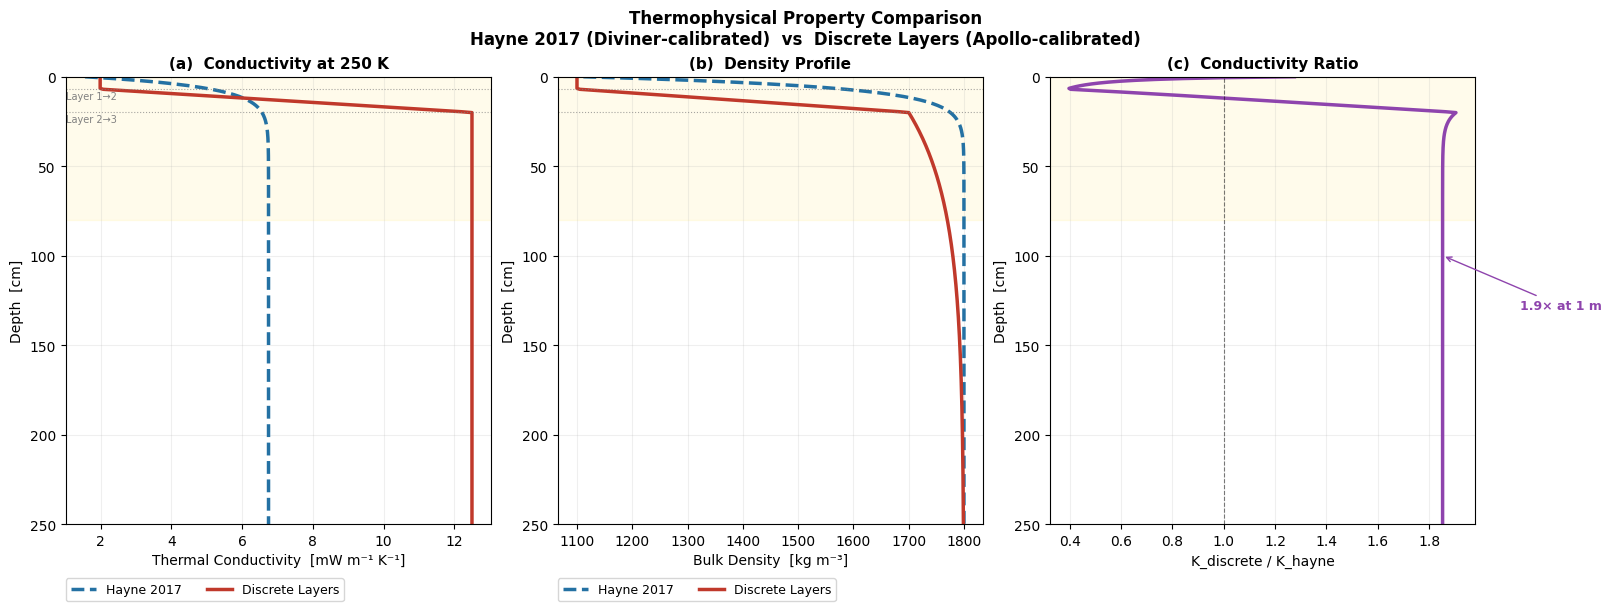

In [40]:
# ===================================================================
# Property comparison: Hayne (2017) vs Discrete Layers
# Lunar-Clean style — deep red for Discrete, deep blue for Hayne
# ===================================================================

CLR_HAYNE = '#2471A3'    # deep blue
CLR_DISC  = '#C0392B'    # deep red

z_plot_prop = np.linspace(0.001, 2.5, 500)   # m
T_const = np.full_like(z_plot_prop, 250.0)    # K — representative T

# Compute properties at all depths
K_hayne_prop = conductivity_hayne(T_const, z_plot_prop)
K_disc_prop  = k_discrete(T_const, z_plot_prop)
rho_hayne_prop = density_hayne(z_plot_prop)
rho_disc_prop  = rho_discrete(z_plot_prop)

fig, axes = plt.subplots(1, 3, figsize=(16, 6), constrained_layout=True)

# ---- Panel A: Thermal conductivity ----
ax = axes[0]
ax.plot(K_hayne_prop * 1e3, z_plot_prop * 100, color=CLR_HAYNE, lw=2.5,
        ls='--', label='Hayne 2017')
ax.plot(K_disc_prop * 1e3, z_plot_prop * 100, color=CLR_DISC, lw=2.5,
        ls='-', label='Discrete Layers')

# Layer boundaries
for h_cm, lbl in [(H_LAYER1*100, 'Layer 1→2'), (H_LAYER2*100, 'Layer 2→3')]:
    ax.axhline(h_cm, color='gray', lw=0.8, ls=':', alpha=0.7)
    ax.text(ax.get_xlim()[0] if ax.get_xlim()[0] > 0 else 0.1, h_cm + 1,
            lbl, fontsize=7, color='gray', va='top')

ax.axhspan(0, MIN_DEPTH_CM, color='gold', alpha=0.08, zorder=0)
ax.set_xlabel('Thermal Conductivity  [mW m⁻¹ K⁻¹]', fontsize=10)
ax.set_ylabel('Depth  [cm]', fontsize=10)
ax.set_title('(a)  Conductivity at 250 K', fontsize=11, weight='bold')
ax.invert_yaxis()
ax.set_ylim(250, 0)
ax.legend(fontsize=9, loc='upper left',
          bbox_to_anchor=(0.0, -0.12), ncol=2, borderaxespad=0.0)
ax.grid(True, alpha=0.2)

# ---- Panel B: Density ----
ax = axes[1]
ax.plot(rho_hayne_prop, z_plot_prop * 100, color=CLR_HAYNE, lw=2.5,
        ls='--', label='Hayne 2017')
ax.plot(rho_disc_prop, z_plot_prop * 100, color=CLR_DISC, lw=2.5,
        ls='-', label='Discrete Layers')

for h_cm in [H_LAYER1*100, H_LAYER2*100]:
    ax.axhline(h_cm, color='gray', lw=0.8, ls=':', alpha=0.7)

ax.axhspan(0, MIN_DEPTH_CM, color='gold', alpha=0.08, zorder=0)
ax.set_xlabel('Bulk Density  [kg m⁻³]', fontsize=10)
ax.set_ylabel('Depth  [cm]', fontsize=10)
ax.set_title('(b)  Density Profile', fontsize=11, weight='bold')
ax.invert_yaxis()
ax.set_ylim(250, 0)
ax.legend(fontsize=9, loc='upper left',
          bbox_to_anchor=(0.0, -0.12), ncol=2, borderaxespad=0.0)
ax.grid(True, alpha=0.2)

# ---- Panel C: Conductivity ratio ----
ax = axes[2]
ratio = K_disc_prop / K_hayne_prop
ax.plot(ratio, z_plot_prop * 100, color='#8E44AD', lw=2.5)
ax.axvline(1.0, color='k', lw=0.8, ls='--', alpha=0.5)
ax.axhspan(0, MIN_DEPTH_CM, color='gold', alpha=0.08, zorder=0)
ax.set_xlabel('K_discrete / K_hayne', fontsize=10)
ax.set_ylabel('Depth  [cm]', fontsize=10)
ax.set_title('(c)  Conductivity Ratio', fontsize=11, weight='bold')
ax.invert_yaxis()
ax.set_ylim(250, 0)
ax.grid(True, alpha=0.2)

# Annotate the deep ratio
iz_1m = np.argmin(np.abs(z_plot_prop - 1.0))
ax.annotate(f'{ratio[iz_1m]:.1f}× at 1 m', xy=(ratio[iz_1m], 100),
            fontsize=9, color='#8E44AD', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#8E44AD'),
            xytext=(ratio[iz_1m]+0.3, 130))

fig.suptitle('Thermophysical Property Comparison\n'
             'Hayne 2017 (Diviner-calibrated)  vs  Discrete Layers (Apollo-calibrated)',
             fontsize=12, weight='bold')
plt.show()

## 3  Model vs Observation

Three figures:

1. **Hayne 2017 only** — profile + residuals + statistics
2. **Discrete Layers only** — profile + residuals + statistics
3. **Both models together** — overlaid profiles + dual residuals + head-to-head statistics

────────────────────────────────────────────────────────────
Figure 3a: Hayne 2017 only


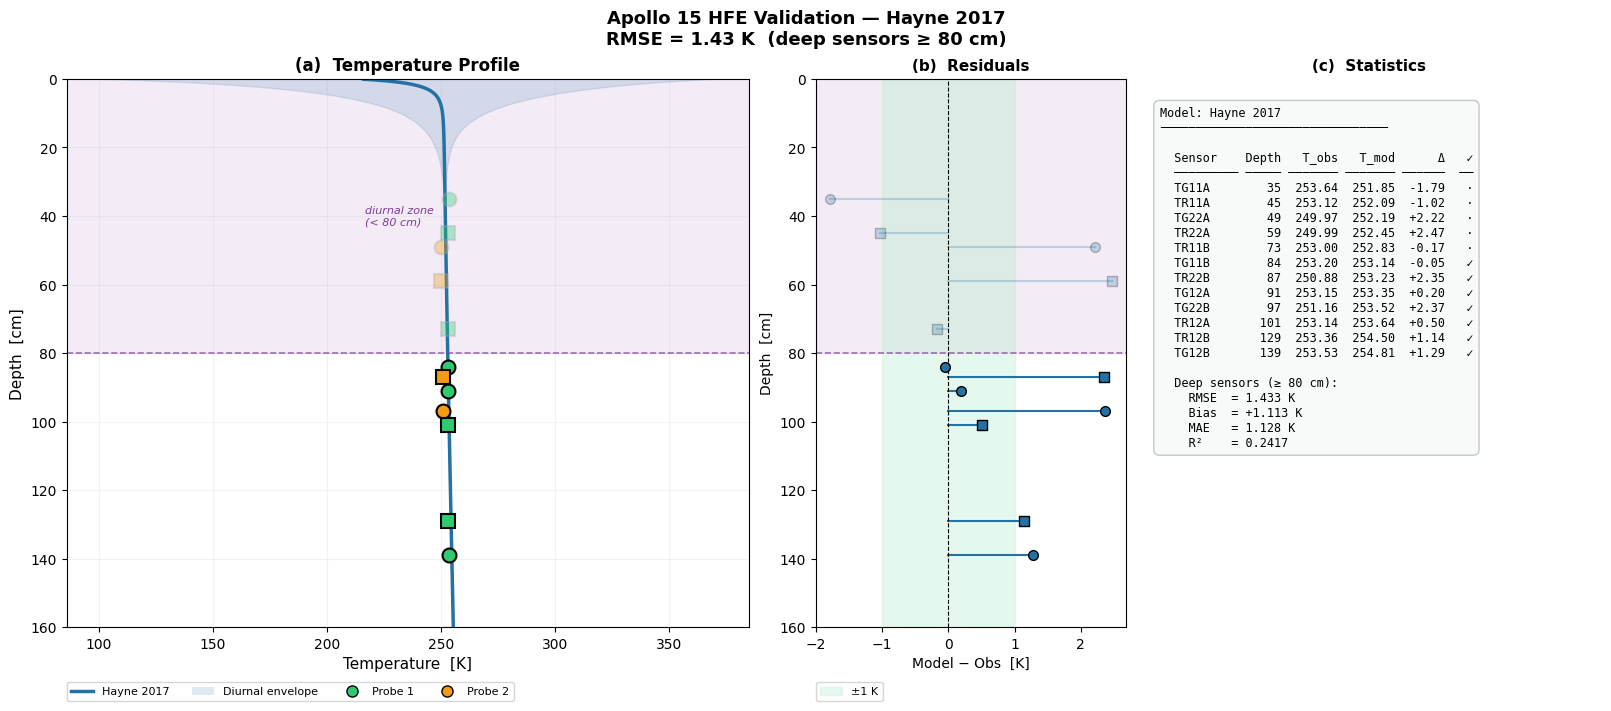

────────────────────────────────────────────────────────────
Figure 3b: Discrete Layers only


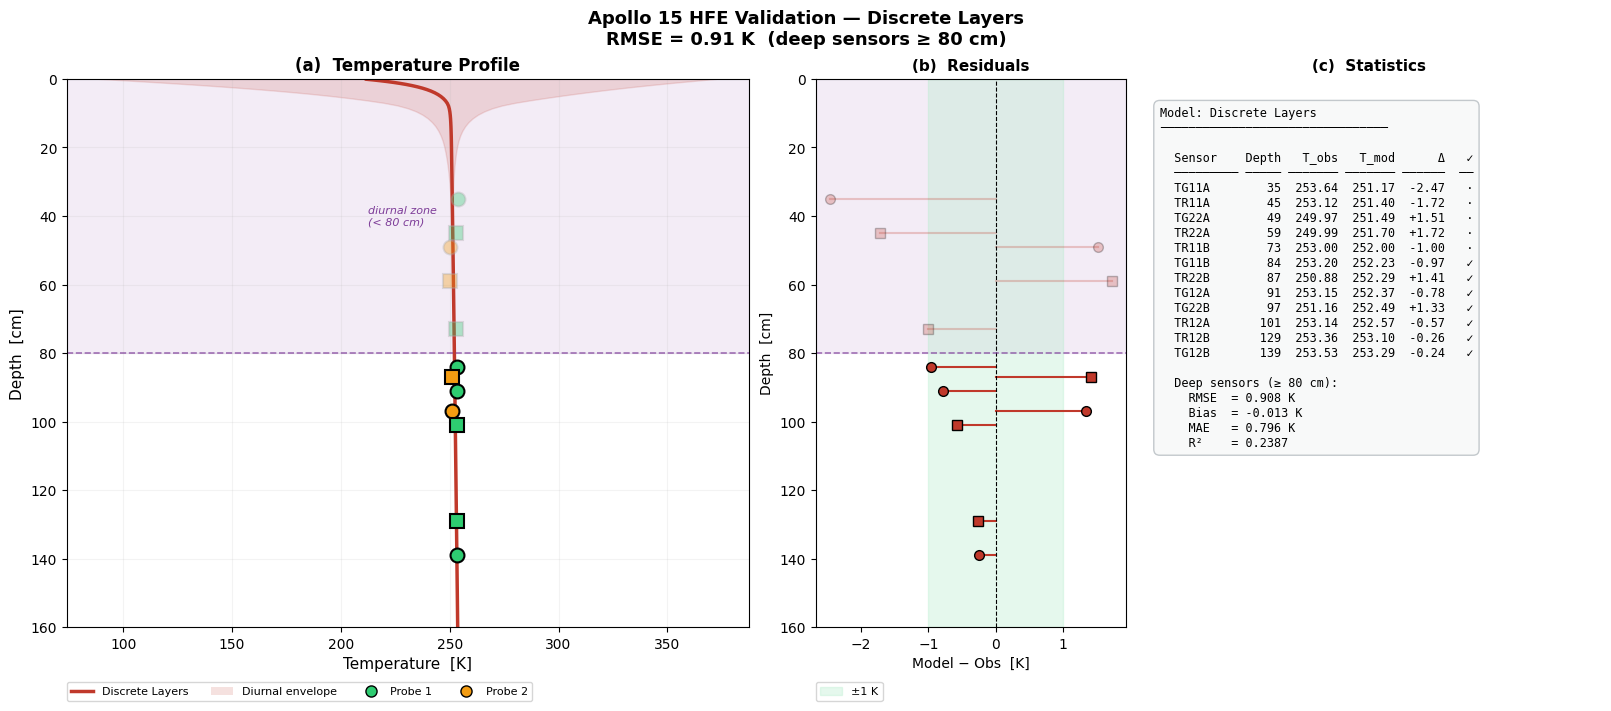

────────────────────────────────────────────────────────────
Figure 3c: Both models together


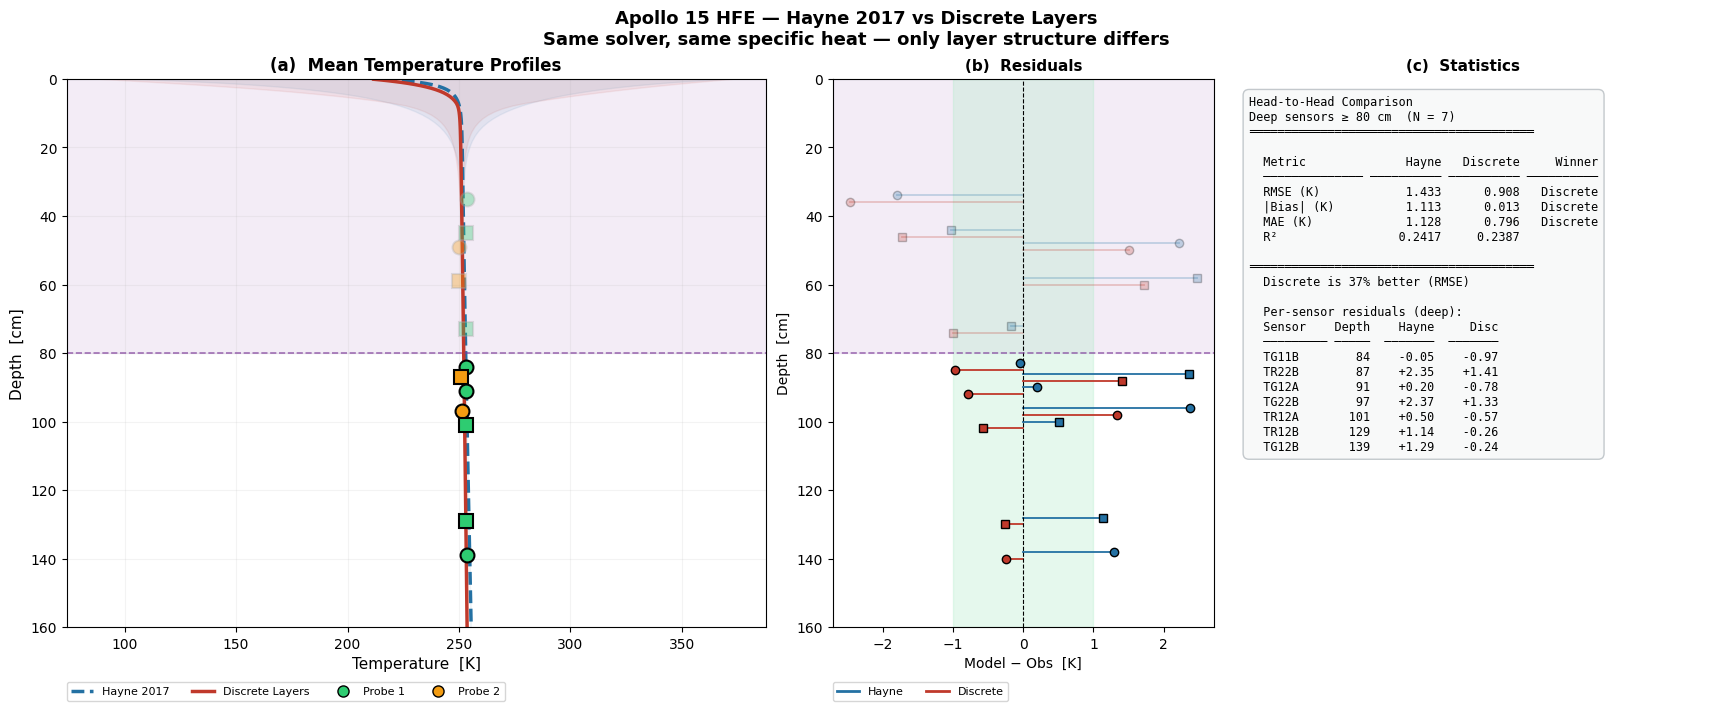

In [41]:
# ===================================================================
# Model vs Observation — three figures
# ===================================================================
from scipy.stats import pearsonr
from matplotlib.lines import Line2D

# --- Shared colours ---
CLR_HAYNE = '#2471A3'    # deep blue
CLR_DISC  = '#C0392B'    # deep red
ZONE_CLR  = '#E8DAEF'    # soft lavender for diurnal zone (replaces gold)
ZONE_LINE = '#7D3C98'    # purple line at boundary

# --- Precompute everything ---
T_mean_hayne = out.T.mean(axis=1)
T_mean_disc  = out_disc.T.mean(axis=1)

T_hayne_at_sensor = np.interp(depth_cm_all, z_cm_model, T_mean_hayne)
T_disc_at_sensor  = np.interp(depth_cm_all, z_cm_model, T_mean_disc)

resid_hayne_all = T_hayne_at_sensor - T_eq_all
resid_disc_all  = T_disc_at_sensor  - T_eq_all
resid_hayne_deep = resid_hayne_all[deep_mask]
resid_disc_deep  = resid_disc_all[deep_mask]

rmse_hayne_deep = np.sqrt(np.mean(resid_hayne_deep**2))
bias_hayne_deep = np.mean(resid_hayne_deep)
mae_hayne_deep  = np.mean(np.abs(resid_hayne_deep))
r_hayne_deep, _ = pearsonr(T_eq_deep, T_hayne_at_sensor[deep_mask])

rmse_disc_deep = np.sqrt(np.mean(resid_disc_deep**2))
bias_disc_deep = np.mean(resid_disc_deep)
mae_disc_deep  = np.mean(np.abs(resid_disc_deep))
r_disc_deep, _ = pearsonr(T_eq_deep, T_disc_at_sensor[deep_mask])


# ===================================================================
# Helper: single-model figure (profile + residuals + stats text)
# ===================================================================
def plot_single_model(model_name, out_m, T_mean_m, T_at_sensor, resid_all,
                      resid_deep, color, rmse_d, bias_d, mae_d, r2_d):
    fig, axes = plt.subplots(1, 3, figsize=(16, 7),
                              gridspec_kw={'width_ratios': [2.2, 1, 1.5]},
                              constrained_layout=True)

    # ---- Panel A: Temperature profile ----
    ax = axes[0]
    T_max_m = out_m.T.max(axis=1)
    T_min_m = out_m.T.min(axis=1)
    ax.fill_betweenx(z_cm_model, T_min_m, T_max_m,
                      alpha=0.15, color=color, label='Diurnal envelope')
    ax.plot(T_mean_m, z_cm_model, color=color, lw=2.5, label=f'{model_name} (mean)')

    for i, s in enumerate(sensors_all):
        marker = 'o' if s['stype'] == 'TG' else 's'
        fc = '#2ECC71' if s['probe'] == 1 else '#F39C12'
        ec = 'k' if deep_mask[i] else '#AAAAAA'
        alpha_s = 1.0 if deep_mask[i] else 0.35
        ax.plot(s['T_eq'], s['depth_cm'], marker, ms=10, mfc=fc, mec=ec,
                mew=1.5, zorder=5, alpha=alpha_s)

    ax.axhspan(0, MIN_DEPTH_CM, color=ZONE_CLR, alpha=0.5, zorder=0)
    ax.axhline(MIN_DEPTH_CM, color=ZONE_LINE, lw=1.2, ls='--', alpha=0.7)
    ax.text(T_mean_m.min()+0.5, MIN_DEPTH_CM/2,
            f'diurnal zone\n(< {MIN_DEPTH_CM} cm)', fontsize=8,
            ha='left', va='center', color=ZONE_LINE, style='italic')

    handles = [
        Line2D([0],[0], color=color, lw=2.5, label=f'{model_name}'),
        plt.Rectangle((0,0),1,1, fc=color, alpha=0.15, label='Diurnal envelope'),
        Line2D([0],[0], marker='o', color='w', mfc='#2ECC71', mec='k', ms=8, label='Probe 1'),
        Line2D([0],[0], marker='o', color='w', mfc='#F39C12', mec='k', ms=8, label='Probe 2'),
    ]
    ax.legend(handles=handles, fontsize=8, loc='upper left',
              bbox_to_anchor=(0.0, -0.10), ncol=4, borderaxespad=0.0)
    ax.set_xlabel('Temperature  [K]', fontsize=11)
    ax.set_ylabel('Depth  [cm]', fontsize=11)
    ax.set_title('(a)  Temperature Profile', fontsize=12, weight='bold')
    ax.invert_yaxis()
    ax.set_ylim(160, 0)
    ax.grid(True, alpha=0.15)

    # ---- Panel B: Residuals ----
    ax = axes[1]
    for i, s in enumerate(sensors_all):
        alpha_s = 1.0 if deep_mask[i] else 0.25
        marker = 'o' if s['stype'] == 'TG' else 's'
        ax.plot([0, resid_all[i]], [s['depth_cm']]*2, '-',
                color=color, alpha=alpha_s, lw=1.5)
        ax.plot(resid_all[i], s['depth_cm'], marker, ms=7,
                mfc=color, mec='k', alpha=alpha_s, zorder=5)
    ax.axvline(0, color='k', lw=0.8, ls='--')
    ax.axvspan(-1, 1, color='#ABEBC6', alpha=0.3, label='±1 K')
    ax.axhspan(0, MIN_DEPTH_CM, color=ZONE_CLR, alpha=0.5, zorder=0)
    ax.axhline(MIN_DEPTH_CM, color=ZONE_LINE, lw=1.2, ls='--', alpha=0.7)
    ax.set_xlabel('Model − Obs  [K]', fontsize=10)
    ax.set_ylabel('Depth  [cm]', fontsize=10)
    ax.set_title('(b)  Residuals', fontsize=11, weight='bold')
    ax.invert_yaxis()
    ax.set_ylim(160, 0)
    ax.legend(fontsize=8, loc='upper left',
              bbox_to_anchor=(0.0, -0.10), borderaxespad=0.0)

    # ---- Panel C: Stats text ----
    ax = axes[2]
    ax.axis('off')

    lines = []
    lines.append(f'Model: {model_name}')
    lines.append(f'─' * 32)
    lines.append(f'')
    lines.append(f'  {"Sensor":<9} {"Depth":>5} {"T_obs":>7} {"T_mod":>7} {"Δ":>6}  {"✓":>2}')
    lines.append(f'  {"─"*9} {"─"*5} {"─"*7} {"─"*7} {"─"*6}  {"─"*2}')
    for i, s in enumerate(sensors_all):
        tag = '✓' if deep_mask[i] else '·'
        lines.append(
            f'  {s["sensor"]:<9} {s["depth_cm"]:>5.0f} '
            f'{s["T_eq"]:>7.2f} {T_at_sensor[i]:>7.2f} '
            f'{resid_all[i]:>+6.2f}  {tag:>2}'
        )
    lines.append(f'')
    lines.append(f'  Deep sensors (≥ {MIN_DEPTH_CM} cm):')
    lines.append(f'    RMSE  = {rmse_d:.3f} K')
    lines.append(f'    Bias  = {bias_d:+.3f} K')
    lines.append(f'    MAE   = {mae_d:.3f} K')
    lines.append(f'    R²    = {r2_d:.4f}')

    ax.text(0.05, 0.95, '\n'.join(lines), transform=ax.transAxes,
            fontsize=8.5, fontfamily='monospace', verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#F8F9F9',
                      edgecolor='#BDC3C7', alpha=0.9))
    ax.set_title('(c)  Statistics', fontsize=11, weight='bold')

    fig.suptitle(f'Apollo 15 HFE Validation — {model_name}\n'
                 f'RMSE = {rmse_d:.2f} K  (deep sensors ≥ {MIN_DEPTH_CM} cm)',
                 fontsize=13, weight='bold')
    plt.show()


# ===================================================================
# Figure 3a: Hayne only
# ===================================================================
print('─' * 60)
print('Figure 3a: Hayne 2017 only')
plot_single_model('Hayne 2017', out, T_mean_hayne, T_hayne_at_sensor,
                  resid_hayne_all, resid_hayne_deep, CLR_HAYNE,
                  rmse_hayne_deep, bias_hayne_deep, mae_hayne_deep,
                  r_hayne_deep**2)

# ===================================================================
# Figure 3b: Discrete only
# ===================================================================
print('─' * 60)
print('Figure 3b: Discrete Layers only')
plot_single_model('Discrete Layers', out_disc, T_mean_disc, T_disc_at_sensor,
                  resid_disc_all, resid_disc_deep, CLR_DISC,
                  rmse_disc_deep, bias_disc_deep, mae_disc_deep,
                  r_disc_deep**2)


# ===================================================================
# Figure 3c: Both models together
# ===================================================================
print('─' * 60)
print('Figure 3c: Both models together')

fig, axes = plt.subplots(1, 3, figsize=(17, 7),
                          gridspec_kw={'width_ratios': [2.2, 1.2, 1.5]},
                          constrained_layout=True)

# ---- Panel A: Overlaid profiles ----
ax = axes[0]
# Envelopes
T_max_h = out.T.max(axis=1);      T_min_h = out.T.min(axis=1)
T_max_d = out_disc.T.max(axis=1);  T_min_d = out_disc.T.min(axis=1)
ax.fill_betweenx(z_cm_model, T_min_h, T_max_h, alpha=0.08, color=CLR_HAYNE)
ax.fill_betweenx(z_cm_model, T_min_d, T_max_d, alpha=0.08, color=CLR_DISC)
ax.plot(T_mean_hayne, z_cm_model, color=CLR_HAYNE, lw=2.5, ls='--', label='Hayne 2017')
ax.plot(T_mean_disc,  z_cm_model, color=CLR_DISC,  lw=2.5, ls='-',  label='Discrete Layers')

for i, s in enumerate(sensors_all):
    marker = 'o' if s['stype'] == 'TG' else 's'
    fc = '#2ECC71' if s['probe'] == 1 else '#F39C12'
    ec = 'k' if deep_mask[i] else '#AAAAAA'
    alpha_s = 1.0 if deep_mask[i] else 0.35
    ax.plot(s['T_eq'], s['depth_cm'], marker, ms=10, mfc=fc, mec=ec,
            mew=1.5, zorder=5, alpha=alpha_s)

handles = [
    Line2D([0],[0], color=CLR_HAYNE, lw=2.5, ls='--', label='Hayne 2017'),
    Line2D([0],[0], color=CLR_DISC,  lw=2.5, ls='-',  label='Discrete Layers'),
    Line2D([0],[0], marker='o', color='w', mfc='#2ECC71', mec='k', ms=8, label='Probe 1'),
    Line2D([0],[0], marker='o', color='w', mfc='#F39C12', mec='k', ms=8, label='Probe 2'),
]
ax.legend(handles=handles, fontsize=8, loc='upper left',
          bbox_to_anchor=(0.0, -0.10), ncol=4, borderaxespad=0.0)
ax.axhspan(0, MIN_DEPTH_CM, color=ZONE_CLR, alpha=0.5, zorder=0)
ax.axhline(MIN_DEPTH_CM, color=ZONE_LINE, lw=1.2, ls='--', alpha=0.7)
ax.set_xlabel('Temperature  [K]', fontsize=11)
ax.set_ylabel('Depth  [cm]', fontsize=11)
ax.set_title('(a)  Mean Temperature Profiles', fontsize=12, weight='bold')
ax.invert_yaxis(); ax.set_ylim(160, 0)
ax.grid(True, alpha=0.15)

# ---- Panel B: Dual residuals ----
ax = axes[1]
offset = 1.0
for i, s in enumerate(sensors_all):
    alpha_s = 1.0 if deep_mask[i] else 0.25
    marker = 'o' if s['stype'] == 'TG' else 's'
    d_cm = s['depth_cm']
    # Hayne
    ax.plot([0, resid_hayne_all[i]], [d_cm - offset]*2, '-',
            color=CLR_HAYNE, alpha=alpha_s, lw=1.3)
    ax.plot(resid_hayne_all[i], d_cm - offset, marker, ms=6,
            mfc=CLR_HAYNE, mec='k', alpha=alpha_s, zorder=5)
    # Discrete
    ax.plot([0, resid_disc_all[i]], [d_cm + offset]*2, '-',
            color=CLR_DISC, alpha=alpha_s, lw=1.3)
    ax.plot(resid_disc_all[i], d_cm + offset, marker, ms=6,
            mfc=CLR_DISC, mec='k', alpha=alpha_s, zorder=5)

ax.axvline(0, color='k', lw=0.8, ls='--')
ax.axvspan(-1, 1, color='#ABEBC6', alpha=0.3, label='±1 K')
ax.axhspan(0, MIN_DEPTH_CM, color=ZONE_CLR, alpha=0.5, zorder=0)
ax.axhline(MIN_DEPTH_CM, color=ZONE_LINE, lw=1.2, ls='--', alpha=0.7)
res_handles = [
    Line2D([0],[0], color=CLR_HAYNE, lw=2, label='Hayne'),
    Line2D([0],[0], color=CLR_DISC, lw=2, label='Discrete'),
]
ax.legend(handles=res_handles, fontsize=8, loc='upper left',
          bbox_to_anchor=(0.0, -0.10), ncol=2, borderaxespad=0.0)
ax.set_xlabel('Model − Obs  [K]', fontsize=10)
ax.set_ylabel('Depth  [cm]', fontsize=10)
ax.set_title('(b)  Residuals', fontsize=11, weight='bold')
ax.invert_yaxis(); ax.set_ylim(160, 0)

# ---- Panel C: Head-to-head stats ----
ax = axes[2]
ax.axis('off')

lines = []
lines.append(f'Head-to-Head Comparison')
lines.append(f'Deep sensors ≥ {MIN_DEPTH_CM} cm  (N = {deep_mask.sum()})')
lines.append(f'{"═"*40}')
lines.append(f'')
lines.append(f'  {"Metric":<14} {"Hayne":>10} {"Discrete":>10} {"Winner":>10}')
lines.append(f'  {"─"*14} {"─"*10} {"─"*10} {"─"*10}')
for label, vh, vd in [
    ('RMSE (K)', rmse_hayne_deep, rmse_disc_deep),
    ('|Bias| (K)', abs(bias_hayne_deep), abs(bias_disc_deep)),
    ('MAE (K)', mae_hayne_deep, mae_disc_deep),
]:
    w = 'Discrete' if vd < vh else ('Hayne' if vh < vd else 'Tie')
    lines.append(f'  {label:<14} {vh:>10.3f} {vd:>10.3f} {w:>10}')
lines.append(f'  {"R²":<14} {r_hayne_deep**2:>10.4f} {r_disc_deep**2:>10.4f}')

lines.append(f'')
lines.append(f'{"═"*40}')
pct = (1 - rmse_disc_deep / rmse_hayne_deep) * 100
lines.append(f'  Discrete is {pct:.0f}% better (RMSE)')
lines.append(f'')
lines.append(f'  Per-sensor residuals (deep):')
lines.append(f'  {"Sensor":<9} {"Depth":>5}  {"Hayne":>7}  {"Disc":>7}')
lines.append(f'  {"─"*9} {"─"*5}  {"─"*7}  {"─"*7}')
for i, s in enumerate(sensors_all):
    if deep_mask[i]:
        lines.append(
            f'  {s["sensor"]:<9} {s["depth_cm"]:>5.0f}  '
            f'{resid_hayne_all[i]:>+7.2f}  {resid_disc_all[i]:>+7.2f}'
        )

ax.text(0.05, 0.97, '\n'.join(lines), transform=ax.transAxes,
        fontsize=8.5, fontfamily='monospace', verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#F8F9F9',
                  edgecolor='#BDC3C7', alpha=0.9))
ax.set_title('(c)  Statistics', fontsize=11, weight='bold')

fig.suptitle('Apollo 15 HFE — Hayne 2017 vs Discrete Layers\n'
             'Same solver, same specific heat — only layer structure differs',
             fontsize=13, weight='bold')
plt.show()

## 4  Diurnal Temperature Cycles  —  Model Comparison

Diurnal temperature variation at selected depths for both models.  The discrete
model's higher deep conductivity leads to faster thermal-wave propagation and
a different amplitude decay profile.  Below ~80 cm the diurnal signal is
negligible in both models — confirming these sensors measure the steady-state
geothermal gradient.

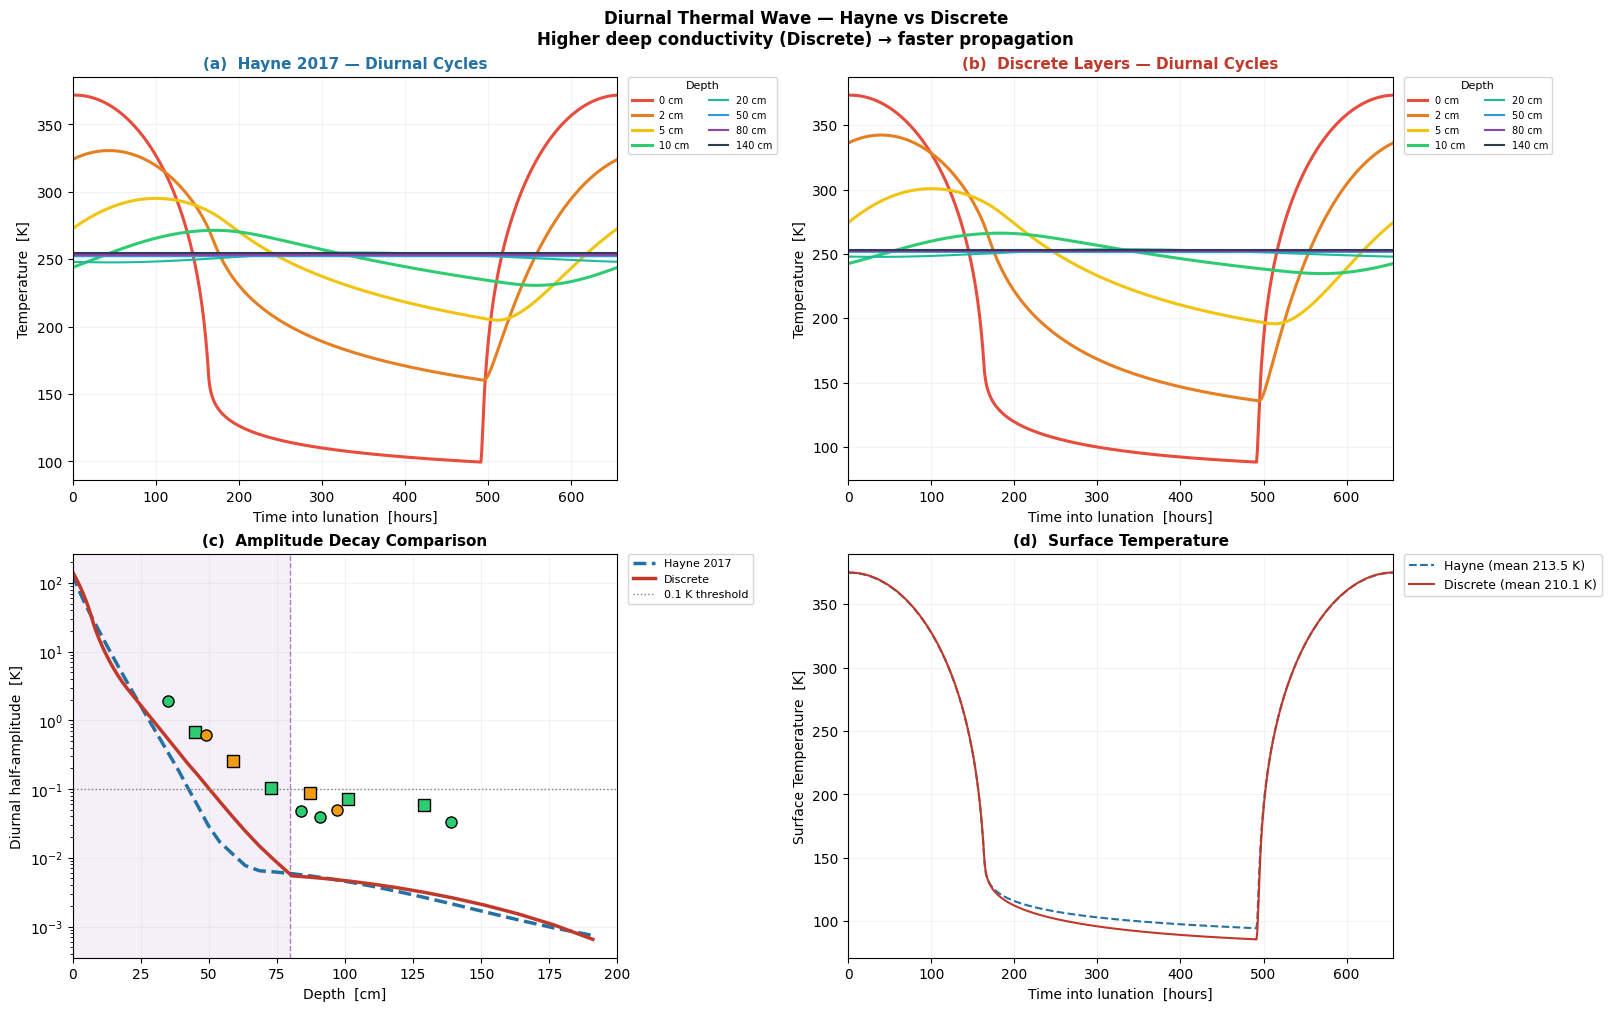

In [42]:
# ===================================================================
# Diurnal cycles & amplitude decay — dual model comparison
# ===================================================================
diurnal_depths_cm = [0, 2, 5, 10, 20, 50, 80, 140]
time_hr = t_s / 3600.0

fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

# Use a high-contrast discrete colormap for depth lines
depth_colors = {
    0:   '#E74C3C',   # red
    2:   '#E67E22',   # orange
    5:   '#F1C40F',   # yellow
    10:  '#2ECC71',   # green
    20:  '#1ABC9C',   # teal
    50:  '#3498DB',   # blue
    80:  '#8E44AD',   # purple
    140: '#2C3E50',   # dark
}

# ---- Panel A: Hayne diurnal curves ----
ax = axes[0, 0]
for d_cm in diurnal_depths_cm:
    iz = np.argmin(np.abs(z_cm_model - d_cm))
    lw = 2.2 if d_cm <= 10 else 1.5
    ax.plot(time_hr, out.T[iz, :], color=depth_colors[d_cm], lw=lw,
            label=f'{d_cm} cm')
ax.set_xlabel('Time into lunation  [hours]')
ax.set_ylabel('Temperature  [K]')
ax.set_title('(a)  Hayne 2017 — Diurnal Cycles', fontsize=11, weight='bold',
              color=CLR_HAYNE)
ax.legend(ncol=2, fontsize=7, title='Depth', title_fontsize=8,
          loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
ax.set_xlim(0, time_hr[-1])
ax.grid(True, alpha=0.15)

# ---- Panel B: Discrete diurnal curves ----
ax = axes[0, 1]
for d_cm in diurnal_depths_cm:
    iz = np.argmin(np.abs(z_cm_model - d_cm))
    lw = 2.2 if d_cm <= 10 else 1.5
    ax.plot(time_hr, out_disc.T[iz, :], color=depth_colors[d_cm], lw=lw,
            label=f'{d_cm} cm')
ax.set_xlabel('Time into lunation  [hours]')
ax.set_ylabel('Temperature  [K]')
ax.set_title('(b)  Discrete Layers — Diurnal Cycles', fontsize=11, weight='bold',
              color=CLR_DISC)
ax.legend(ncol=2, fontsize=7, title='Depth', title_fontsize=8,
          loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
ax.set_xlim(0, time_hr[-1])
ax.grid(True, alpha=0.15)

# ---- Panel C: Amplitude decay comparison ----
ax = axes[1, 0]
z_cm_fine = z_cm_model[z_cm_model <= 200]
idx_fine  = np.where(z_cm_model <= 200)[0]

amp_hayne = 0.5 * (out.T.max(axis=1) - out.T.min(axis=1))
amp_disc  = 0.5 * (out_disc.T.max(axis=1) - out_disc.T.min(axis=1))

ax.semilogy(z_cm_fine, amp_hayne[idx_fine], color=CLR_HAYNE, lw=2.5,
            ls='--', label='Hayne 2017')
ax.semilogy(z_cm_fine, amp_disc[idx_fine], color=CLR_DISC, lw=2.5,
            ls='-', label='Discrete')

# Sensor observed σ
for i, s in enumerate(sensors_all):
    marker = 'o' if s['stype'] == 'TG' else 's'
    fc = '#2ECC71' if s['probe'] == 1 else '#F39C12'
    ax.plot(s['depth_cm'], s['T_std'], marker, ms=8, mfc=fc, mec='k', zorder=5)

ax.axvspan(0, MIN_DEPTH_CM, color=ZONE_CLR, alpha=0.4)
ax.axvline(MIN_DEPTH_CM, color=ZONE_LINE, lw=1, ls='--', alpha=0.6)
ax.axhline(0.1, color='gray', ls=':', lw=1, label='0.1 K threshold')
ax.set_xlabel('Depth  [cm]')
ax.set_ylabel('Diurnal half-amplitude  [K]')
ax.set_title('(c)  Amplitude Decay Comparison', fontsize=11, weight='bold')
ax.legend(fontsize=8, loc='upper left',
          bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
ax.set_xlim(0, 200)
ax.grid(True, alpha=0.15)

# ---- Panel D: Surface temperature comparison ----
ax = axes[1, 1]
ax.plot(time_hr, out.T_surface, color=CLR_HAYNE, lw=1.5, ls='--',
        label=f'Hayne (mean {np.mean(out.T_surface):.1f} K)')
ax.plot(time_hr, out_disc.T_surface, color=CLR_DISC, lw=1.5, ls='-',
        label=f'Discrete (mean {np.mean(out_disc.T_surface):.1f} K)')
ax.set_xlabel('Time into lunation  [hours]')
ax.set_ylabel('Surface Temperature  [K]')
ax.set_title('(d)  Surface Temperature', fontsize=11, weight='bold')
ax.legend(fontsize=9, loc='upper left',
          bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
ax.set_xlim(0, time_hr[-1])
ax.grid(True, alpha=0.15)

fig.suptitle('Diurnal Thermal Wave — Hayne vs Discrete\n'
             'Higher deep conductivity (Discrete) → faster propagation',
             fontsize=12, weight='bold')
plt.show()

## 5  Subsurface Temperature Heatmaps — Side by Side

Temperature as a function of depth and time for both models, plotted with the
same colour scale so differences are immediately visible.  The right panel
shows the **temperature difference** (Discrete − Hayne) to highlight where and
when the models diverge most.

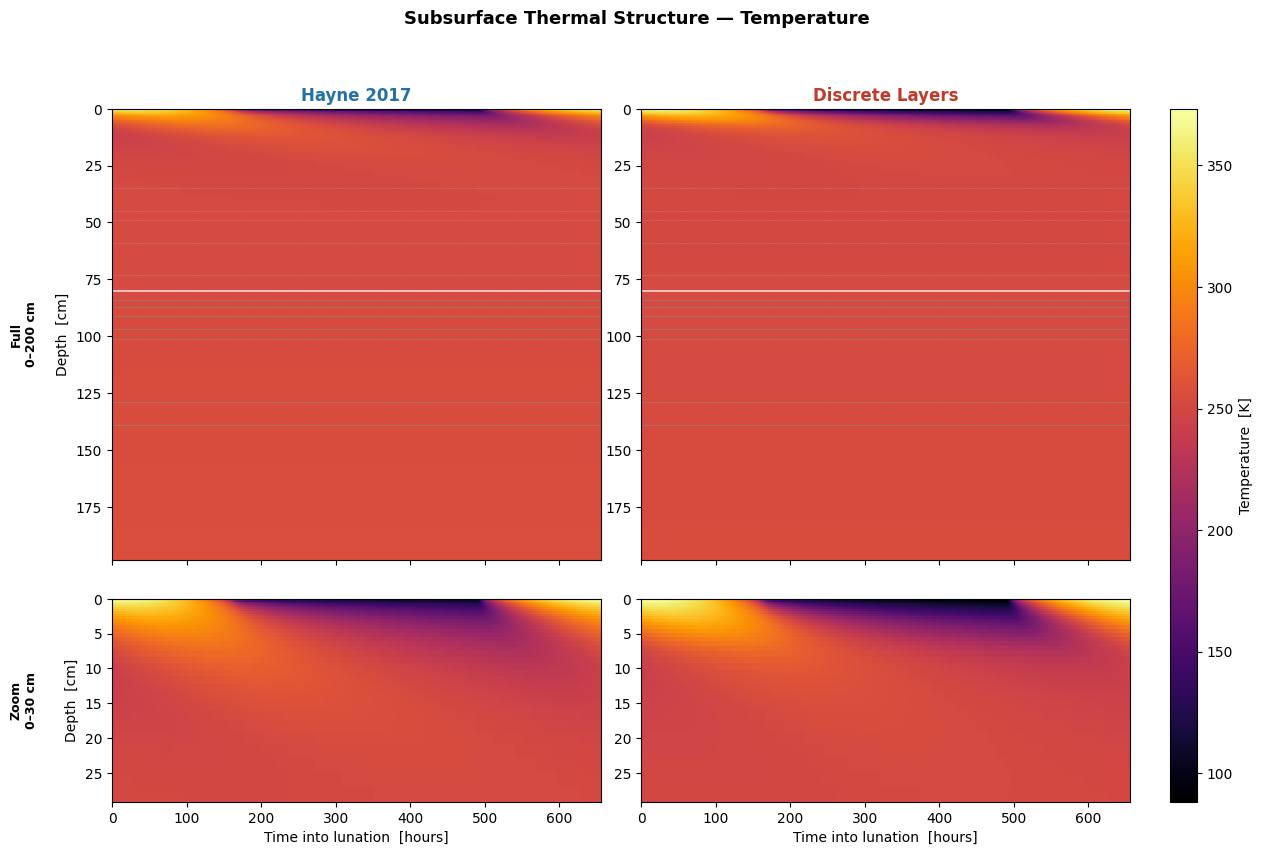

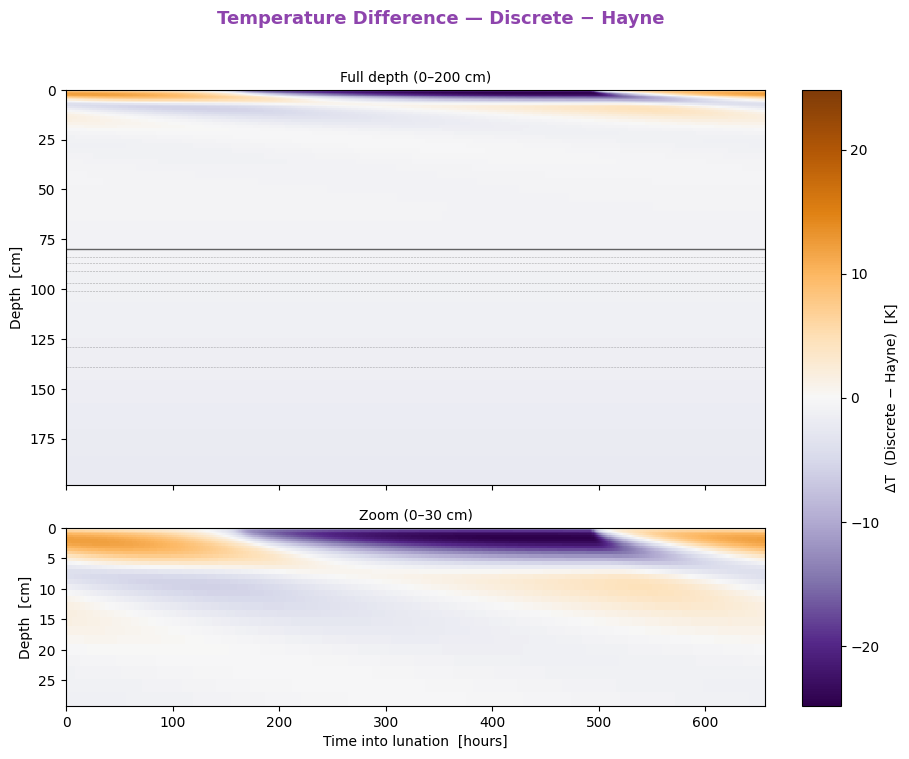

In [29]:
# ===================================================================
# Subsurface heatmaps — Hayne vs Discrete
# Row 1: full depth (0–200 cm)   Row 2: zoomed (0–30 cm)
# Colorbars are drawn in dedicated side axes (never over data)
# ===================================================================
depth_limit_cm = 200
zoom_limit_cm  = 30

mask_full = z_cm_model <= depth_limit_cm
mask_zoom = z_cm_model <= zoom_limit_cm
z_full = z_cm_model[mask_full]
z_zoom = z_cm_model[mask_zoom]

T_h_full = out.T[mask_full, :]
T_d_full = out_disc.T[mask_full, :]
T_diff_full = T_d_full - T_h_full

T_h_zoom = out.T[mask_zoom, :]
T_d_zoom = out_disc.T[mask_zoom, :]
T_diff_zoom = T_d_zoom - T_h_zoom

vmin = min(T_h_full.min(), T_d_full.min())
vmax = max(T_h_full.max(), T_d_full.max())
dT_abs = max(abs(T_diff_full.min()), abs(T_diff_full.max()))

# --- Figure 5a: Temperature heatmaps (Hayne + Discrete, full + zoom) ---
fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(
    nrows=2,
    ncols=3,
    width_ratios=[1.0, 1.0, 0.055],
    height_ratios=[1.0, 0.45],
    wspace=0.12,
    hspace=0.12,
)

axes = np.array([
    [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
    [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])],
])
cax_temp = fig.add_subplot(gs[:, 2])

for col, (out_m, title, clr) in enumerate([
    (out, 'Hayne 2017', CLR_HAYNE),
    (out_disc, 'Discrete Layers', CLR_DISC),
]):
    # Full depth
    ax = axes[0, col]
    T_f = out_m.T[mask_full, :]
    im = ax.pcolormesh(time_hr, z_full, T_f, shading='auto',
                       cmap='inferno', vmin=vmin, vmax=vmax)
    for s_item in sensors_all:
        c = 'cyan' if s_item['depth_cm'] >= MIN_DEPTH_CM else '#BBBBBB'
        ax.axhline(s_item['depth_cm'], color=c, lw=0.4, ls='--', alpha=0.5)
    ax.axhline(MIN_DEPTH_CM, color='white', lw=1.2, ls='-', alpha=0.8)
    ax.set_title(title, fontsize=12, weight='bold', color=clr)
    ax.invert_yaxis()
    ax.tick_params(labelbottom=False)
    if col == 0:
        ax.set_ylabel('Depth  [cm]', fontsize=10)

    # Zoom
    ax = axes[1, col]
    T_z = out_m.T[mask_zoom, :]
    ax.pcolormesh(time_hr, z_zoom, T_z, shading='auto',
                  cmap='inferno', vmin=vmin, vmax=vmax)
    ax.invert_yaxis()
    ax.set_xlabel('Time into lunation  [hours]', fontsize=10)
    if col == 0:
        ax.set_ylabel('Depth  [cm]', fontsize=10)

# Dedicated external colorbar
cbar_t = fig.colorbar(im, cax=cax_temp)
cbar_t.set_label('Temperature  [K]')

# Row labels
axes[0, 0].text(-0.18, 0.5, 'Full\n0–200 cm', transform=axes[0, 0].transAxes,
                fontsize=9, weight='bold', ha='center', va='center', rotation=90)
axes[1, 0].text(-0.18, 0.5, 'Zoom\n0–30 cm', transform=axes[1, 0].transAxes,
                fontsize=9, weight='bold', ha='center', va='center', rotation=90)

fig.suptitle('Subsurface Thermal Structure — Temperature',
             fontsize=13, weight='bold', y=0.99)
plt.show()


# --- Figure 5b: Difference heatmap (Discrete − Hayne, full + zoom) ---
fig2 = plt.figure(figsize=(10, 8))
gs2 = fig2.add_gridspec(
    nrows=2,
    ncols=2,
    width_ratios=[1.0, 0.055],
    height_ratios=[1.0, 0.45],
    wspace=0.10,
    hspace=0.15,
)

ax2_top = fig2.add_subplot(gs2[0, 0])
ax2_bot = fig2.add_subplot(gs2[1, 0])
cax_diff = fig2.add_subplot(gs2[:, 1])

# Full depth
im_d = ax2_top.pcolormesh(time_hr, z_full, T_diff_full, shading='auto',
                          cmap='PuOr_r', vmin=-dT_abs, vmax=dT_abs)
for s_item in sensors_all:
    if s_item['depth_cm'] >= MIN_DEPTH_CM:
        ax2_top.axhline(s_item['depth_cm'], color='k', lw=0.4, ls='--', alpha=0.3)
ax2_top.axhline(MIN_DEPTH_CM, color='k', lw=1, ls='-', alpha=0.6)
ax2_top.set_ylabel('Depth  [cm]', fontsize=10)
ax2_top.set_title('Full depth (0–200 cm)', fontsize=10)
ax2_top.invert_yaxis()
ax2_top.tick_params(labelbottom=False)

# Zoom
ax2_bot.pcolormesh(time_hr, z_zoom, T_diff_zoom, shading='auto',
                   cmap='PuOr_r', vmin=-dT_abs, vmax=dT_abs)
ax2_bot.invert_yaxis()
ax2_bot.set_xlabel('Time into lunation  [hours]', fontsize=10)
ax2_bot.set_ylabel('Depth  [cm]', fontsize=10)
ax2_bot.set_title('Zoom (0–30 cm)', fontsize=10)

# Dedicated external colorbar
cbar_d = fig2.colorbar(im_d, cax=cax_diff)
cbar_d.set_label('ΔT  (Discrete − Hayne)  [K]')

fig2.suptitle('Temperature Difference — Discrete − Hayne',
              fontsize=13, weight='bold', color='#8E44AD', y=0.98)
plt.show()

## 6  Validation Summary

Final quantitative assessment of model accuracy against Apollo 15 HFE readings.

In [36]:
# ===================================================================
# Final Validation Summary — Hayne vs Discrete
# ===================================================================
from scipy.stats import pearsonr

# Recompute for both models (clean)
models = {
    'Hayne 2017': {
        'out': out,
        'T_mean': out.T.mean(axis=1),
        'color': CLR_HAYNE,
    },
    'Discrete': {
        'out': out_disc,
        'T_mean': out_disc.T.mean(axis=1),
        'color': CLR_DISC,
    },
}

print('=' * 90)
print('APOLLO 15 HFE VALIDATION  —  MODEL COMPARISON')
print('=' * 90)

# Per-sensor table header
print(f'\n{"Sensor":<8} {"Depth":>6} {"T_obs":>8}', end='')
for mname in models:
    print(f' │ {"T_"+mname:>12} {"Δ":>7}', end='')
print(f' {"Valid":>6}')
print('-' * 90)

for i, s in enumerate(sensors_all):
    tag = '  ✓' if deep_mask[i] else '  —'
    line = f'{s["sensor"]:<8} {s["depth_cm"]:>6.0f} {s["T_eq"]:>8.2f}'
    for mname, mdata in models.items():
        T_at = np.interp(s['depth_cm'], z_cm_model, mdata['T_mean'])
        resid = T_at - s['T_eq']
        line += f' │ {T_at:>12.2f} {resid:>+7.2f}'
    line += f' {tag:>6}'
    print(line)

print('-' * 90)

# Aggregate statistics
print(f'\n{"":>28} {"Hayne 2017":>16} {"Discrete":>16} {"Winner":>10}')
print(f'{"":>28} {"─"*16} {"─"*16} {"─"*10}')

for subset_label, mask in [('All sensors', np.ones(len(sensors_all), dtype=bool)),
                            (f'Deep (≥{MIN_DEPTH_CM} cm)', deep_mask)]:
    print(f'\n  {subset_label}:')
    d_eq = T_eq_all[mask]
    n_s = mask.sum()
    stats = {}

    for mname, mdata in models.items():
        T_at = np.interp(depth_cm_all[mask], z_cm_model, mdata['T_mean'])
        res = T_at - d_eq
        rmse = np.sqrt(np.mean(res**2))
        bias = np.mean(res)
        mae  = np.mean(np.abs(res))
        r, _  = pearsonr(d_eq, T_at)
        stats[mname] = {'rmse': rmse, 'bias': bias, 'mae': mae, 'r2': r**2,
                         'max_abs': np.max(np.abs(res))}

    sh, sd = stats['Hayne 2017'], stats['Discrete']
    print(f'    {"N":<24} {n_s:>16} {n_s:>16}')
    for label, key in [('RMSE (K)', 'rmse'), ('|Bias| (K)', 'bias'),
                        ('MAE (K)', 'mae'), ('R²', 'r2'), ('Max |Δ| (K)', 'max_abs')]:
        vh = sh[key] if key != 'bias' else abs(sh[key])
        vd = sd[key] if key != 'bias' else abs(sd[key])
        if key == 'r2':
            winner = 'Discrete' if vd > vh else ('Hayne' if vh > vd else 'Tie')
            print(f'    {label:<24} {vh:>16.4f} {vd:>16.4f} {winner:>10}')
        else:
            winner = 'Discrete' if vd < vh else ('Hayne' if vh < vd else 'Tie')
            fmt = '.3f' if key != 'bias' else '+.3f'
            vh_s = f'{sh[key]:{fmt}}' if key == 'bias' else f'{vh:.3f}'
            vd_s = f'{sd[key]:{fmt}}' if key == 'bias' else f'{vd:.3f}'
            print(f'    {label:<24} {vh_s:>16} {vd_s:>16} {winner:>10}')

# Final verdict
print('\n' + '=' * 90)
rmse_h = stats['Hayne 2017']['rmse']
rmse_d = stats['Discrete']['rmse']
best = 'Discrete' if rmse_d < rmse_h else 'Hayne 2017'
print(f'VERDICT (deep sensors):')
print(f'  Hayne 2017 RMSE  = {rmse_h:.3f} K')
print(f'  Discrete   RMSE  = {rmse_d:.3f} K')
if rmse_d < rmse_h:
    pct = (1 - rmse_d / rmse_h) * 100
    print(f'  → Discrete model is {pct:.0f}% better (lower RMSE)')
else:
    pct = (1 - rmse_h / rmse_d) * 100
    print(f'  → Hayne model is {pct:.0f}% better (lower RMSE)')
print(f'\n  Both models share the SAME solver (Crank-Nicolson) and SAME specific heat.')
print(f'  The ONLY difference is the layer structure (conductivity + density vs depth).')
print(f'  Discrete is calibrated to Apollo subsurface heat flow;')
print(f'  Hayne is calibrated to Diviner surface brightness temperatures.')
print('=' * 90)

APOLLO 15 HFE VALIDATION  —  MODEL COMPARISON

Sensor    Depth    T_obs │ T_Hayne 2017       Δ │   T_Discrete       Δ  Valid
------------------------------------------------------------------------------------------
TG11A        35   253.64 │       251.85   -1.79 │       251.17   -2.47      —
TR11A        45   253.12 │       252.09   -1.02 │       251.40   -1.72      —
TG22A        49   249.97 │       252.19   +2.22 │       251.49   +1.51      —
TR22A        59   249.99 │       252.45   +2.47 │       251.70   +1.72      —
TR11B        73   253.00 │       252.83   -0.17 │       252.00   -1.00      —
TG11B        84   253.20 │       253.14   -0.05 │       252.23   -0.97      ✓
TR22B        87   250.88 │       253.23   +2.35 │       252.29   +1.41      ✓
TG12A        91   253.15 │       253.35   +0.20 │       252.37   -0.78      ✓
TG22B        97   251.16 │       253.52   +2.37 │       252.49   +1.33      ✓
TR12A       101   253.14 │       253.64   +0.50 │       252.57   -0.57      ✓
TR12

## 7  Raw Data Timeline & Stabilized Window

The Apollo 15 HFE operated from July 1971 to June 1975, recording subsurface
temperatures at 12 sensor locations across two probes. Immediately after
drilling, probe emplacement injected thermal energy that elevated deep-sensor
temperatures by 20–30 K above equilibrium. This drilling disturbance decays
over months to years.

We now define the stabilized window using a **trend-flat criterion** per sensor:
the earliest tail segment with near-zero long-term slope. If no segment satisfies
the threshold, the method falls back to the final 25% of the record.

Below we show:
1. Full raw timelines with the stabilized-region envelope.
2. Sensor-by-sensor stabilized tails used for equilibrium extraction.

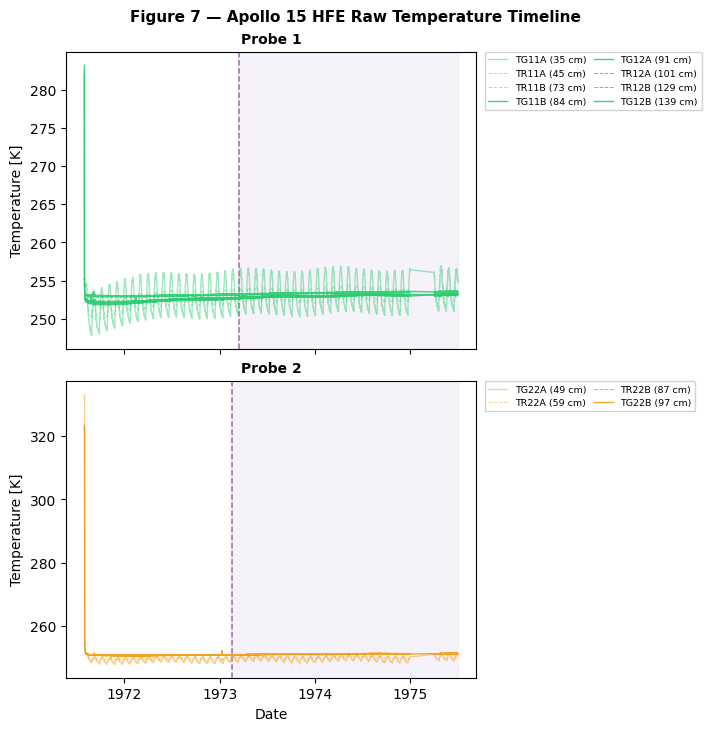

Shaded region starts at earliest sensor-specific stabilized tail


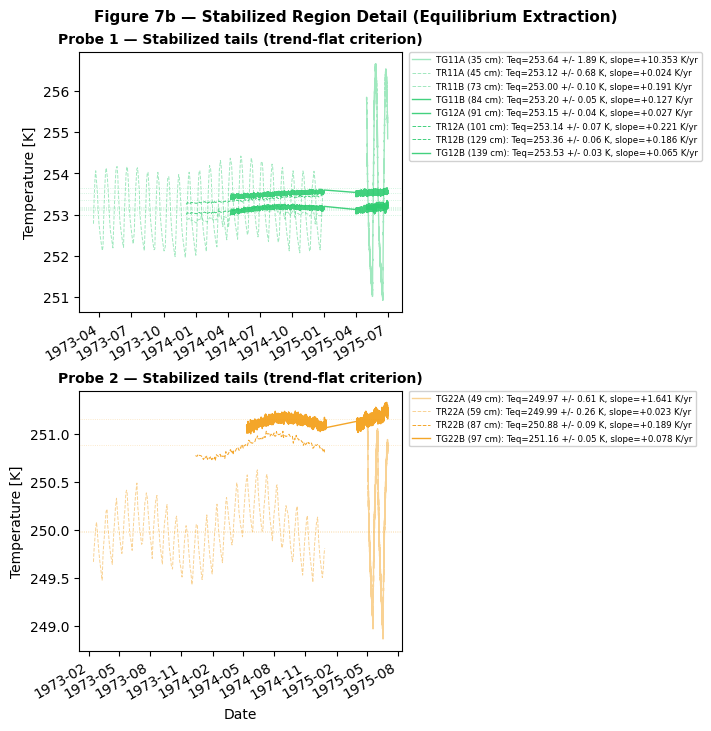

Dashed horizontal lines = equilibrium means from stabilized tails


In [37]:
# ===================================================================
# Raw Data Timeline & Stabilized Window — Apollo 15 HFE
# ===================================================================
from datetime import datetime, timezone
import matplotlib.dates as mdates

# Reload depth tables (explicit)
d1 = load_apollo_hfe_depth('a15', 1)
d2 = load_apollo_hfe_depth('a15', 2)


def iso_to_mdate(iso_arr):
    """Convert ISO-8601 strings to matplotlib date numbers."""
    dates = []
    for s in iso_arr:
        s = s.strip()
        if s.endswith('Z'):
            s = s[:-1] + '+00:00'
        dt = datetime.fromisoformat(s).replace(tzinfo=timezone.utc)
        dates.append(mdates.date2num(dt))
    return np.array(dates)


# Metadata lookup from extracted sensor summary
sensor_meta = {s['sensor']: s for s in sensors_all}

# Consistent colors with previous notebook theme
PROBE_COLORS = {1: '#2ECC71', 2: '#F39C12'}
STAB_CLR = '#E8DAEF'
STAB_EDGE = '#7D3C98'


# ================================================================
# Figure 7a — full timeline + stabilized envelope
# ================================================================
fig, axes = plt.subplots(2, 1, figsize=(7.0, 7.2), sharex=True, constrained_layout=True)

for ax, (probe_num, dtab) in zip(axes, [(1, d1), (2, d2)]):
    sensors_in_probe = np.unique(dtab['sensor'])
    sensor_depths = []
    for sname in sensors_in_probe:
        s = sname.strip()
        if s in sensor_meta:
            sensor_depths.append((s, sensor_meta[s]['depth_cm']))
        else:
            m = dtab['sensor'] == sname
            sensor_depths.append((s, float(np.unique(dtab[m]['depth_cm'])[0])))
    sensor_depths.sort(key=lambda x: x[1])

    start_dates = []
    for sname, depth in sensor_depths:
        m = np.array([ss.strip() == sname for ss in dtab['sensor']])
        sub = dtab[m]
        n = len(sub)
        t_dates = iso_to_mdate(sub['time_iso'])

        # Sensor-specific stabilized window start from extracted metadata
        frac = sensor_meta[sname]['tail_start_frac'] if sname in sensor_meta else 0.75
        i_start = max(0, min(n - 1, int(frac * n)))
        start_dates.append(t_dates[i_start])

        deep = depth >= MIN_DEPTH_CM
        stype = sname[:2]
        alpha = 0.9 if deep else 0.45
        lw = 1.0 if stype == 'TG' else 0.7
        ls = '-' if stype == 'TG' else '--'
        color = PROBE_COLORS[probe_num]

        ax.plot(t_dates, sub['T'], color=color, alpha=alpha, lw=lw, ls=ls,
                label=f'{sname} ({depth:.0f} cm)', rasterized=True)

    # Envelope of stabilization starts (earliest start among sensors)
    t_min = min(start_dates)
    t_max = iso_to_mdate(dtab['time_iso']).max()
    ax.axvspan(t_min, t_max, color=STAB_CLR, alpha=0.35, zorder=0)
    ax.axvline(t_min, color=STAB_EDGE, lw=1.1, ls='--', alpha=0.75, zorder=1)

    ax.set_ylabel('Temperature [K]')
    ax.set_title(f'Probe {probe_num}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=6.8, ncol=2, loc='upper left',
              bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0,
              framealpha=0.9, columnspacing=0.8, handlelength=2.0)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].set_xlabel('Date')
fig.suptitle('Figure 7 — Apollo 15 HFE Raw Temperature Timeline',
             fontsize=11, fontweight='bold')
plt.show()
print('Shaded region starts at earliest sensor-specific stabilized tail')


# ================================================================
# Figure 7b — stabilized tails used for equilibrium extraction
# ================================================================
fig2, axes2 = plt.subplots(2, 1, figsize=(7.0, 7.2), constrained_layout=True)

for ax, (probe_num, dtab) in zip(axes2, [(1, d1), (2, d2)]):
    sensors_in_probe = np.unique(dtab['sensor'])
    sensor_depths = []
    for sname in sensors_in_probe:
        s = sname.strip()
        if s in sensor_meta:
            sensor_depths.append((s, sensor_meta[s]['depth_cm']))
    sensor_depths.sort(key=lambda x: x[1])

    for sname, depth in sensor_depths:
        m = np.array([ss.strip() == sname for ss in dtab['sensor']])
        sub = dtab[m]
        n = len(sub)
        frac = sensor_meta[sname]['tail_start_frac']
        i_start = max(0, min(n - 1, int(frac * n)))
        tail = sub[i_start:]
        t_dates = iso_to_mdate(tail['time_iso'])

        deep = depth >= MIN_DEPTH_CM
        stype = sname[:2]
        alpha = 0.9 if deep else 0.45
        lw = 1.0 if stype == 'TG' else 0.7
        ls = '-' if stype == 'TG' else '--'
        color = PROBE_COLORS[probe_num]

        T_eq = float(np.mean(tail['T']))
        T_std = float(np.std(tail['T']))
        slope = sensor_meta[sname].get('tail_slope_Kyr', np.nan)
        label = (
            f'{sname} ({depth:.0f} cm): '
            f'Teq={T_eq:.2f} +/- {T_std:.2f} K, slope={slope:+.3f} K/yr'
        )

        ax.plot(t_dates, tail['T'], color=color, alpha=alpha, lw=lw, ls=ls,
                label=label, rasterized=True)
        ax.axhline(T_eq, color=color, alpha=0.28, lw=0.6, ls=':')

    ax.set_ylabel('Temperature [K]')
    ax.set_title(f'Probe {probe_num} — Stabilized tails (trend-flat criterion)',
                 fontsize=10, fontweight='bold')
    ax.legend(fontsize=6.2, ncol=1, loc='upper left',
              bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0,
              framealpha=0.9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

axes2[-1].set_xlabel('Date')
fig2.suptitle('Figure 7b — Stabilized Region Detail (Equilibrium Extraction)',
              fontsize=11, fontweight='bold')
plt.show()
print('Dashed horizontal lines = equilibrium means from stabilized tails')